In [11]:
%pip install qbraid --quiet
%pip install qbraid-qir --quiet
%pip install cirq-core --quiet
%pip install amazon-braket-sdk --quiet
%pip install matplotlib --quiet

In [15]:
from qbraid import random_circuit, transpile, ConversionGraph, Conversion
from qbraid.interface import circuits_allclose
from braket.circuits import Circuit
from qbraid import QPROGRAM_REGISTRY

from qbraid_qir import dumps
from qbraid_qir.cirq import cirq_to_qir

In [13]:
QPROGRAM_REGISTRY

{'cirq': cirq.circuits.circuit.Circuit,
 'braket': braket.circuits.circuit.Circuit,
 'braket_ahs': braket.ahs.analog_hamiltonian_simulation.AnalogHamiltonianSimulation,
 'openqasm3': openqasm3.ast.Program,
 'qasm2': str,
 'qasm3': str,
 'qasm2_kirin': str,
 'ionq': qbraid.programs.typer.IonQDict,
 'qubo': qbraid.programs.typer.QuboCoefficientsDict,
 'pyqir': Module,
 'autoqasm': autoqasm.program.program.Program}

Default qBraid-SDK conversion graph with Amazon Braket and Cirq nodes

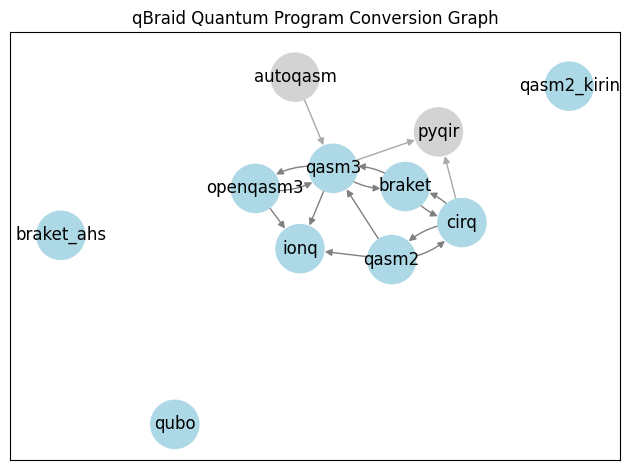

In [16]:
graph = ConversionGraph()

graph.plot()

Add Cirq $\rightarrow$ QIR to qBraid-SDK conversion graph

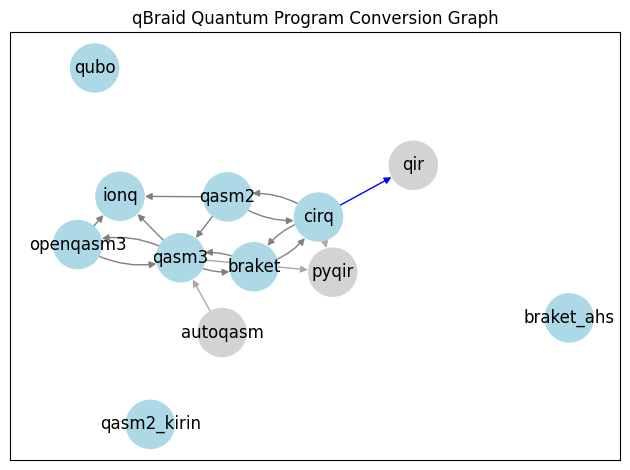

In [17]:
conversion = Conversion("cirq", "qir", cirq_to_qir)

graph.add_conversion(conversion)

graph.plot()

Create Amazon Braket circuit

In [18]:
braket_circuit = Circuit().h(0).cnot(0, 1)

print(braket_circuit)

T  : │  0  │  1  │
      ┌───┐       
q0 : ─┤ H ├───●───
      └───┘   │   
            ┌─┴─┐ 
q1 : ───────┤ X ├─
            └───┘ 
T  : │  0  │  1  │


Convert Amazon Braket circuit to QIR

In [19]:
from qbraid import transpile
from qbraid_qir.qasm3 import qasm3_to_qir

qasm3_str = transpile(braket_circuit, "qasm3")
module = qasm3_to_qir(qasm3_str, name="my-circuit")
ir = str(module)

print(ir)


; ModuleID = 'my-circuit'
source_filename = "my-circuit"

%Qubit = type opaque
%Result = type opaque

define void @my-circuit() #0 {
entry:
  call void @__quantum__rt__initialize(i8* null)
  call void @__quantum__qis__h__body(%Qubit* null)
  call void @__quantum__qis__cnot__body(%Qubit* null, %Qubit* inttoptr (i64 1 to %Qubit*))
  call void @__quantum__rt__result_record_output(%Result* null, i8* null)
  call void @__quantum__rt__result_record_output(%Result* inttoptr (i64 1 to %Result*), i8* null)
  ret void
}

declare void @__quantum__rt__initialize(i8*)

declare void @__quantum__qis__h__body(%Qubit*)

declare void @__quantum__qis__cnot__body(%Qubit*, %Qubit*)

declare void @__quantum__rt__result_record_output(%Result*, i8*)

attributes #0 = { "entry_point" "output_labeling_schema" "qir_profiles"="base" "required_num_qubits"="2" "required_num_results"="2" }

!llvm.module.flags = !{!0, !1, !2, !3}

!0 = !{i32 1, !"qir_major_version", i32 1}
!1 = !{i32 7, !"qir_minor_version", i32 0}
!2

Save QIR output to `.ll` and `.bc` files in current working directory

In [21]:
dumps(module)